In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/dataset/ics_project/Expenses_clean.csv'
df_expenses = pd.read_csv(file_path)

Mounted at /content/drive


In [3]:
print(df_expenses.isnull().sum())

print("Dataset shape:", df_expenses.shape)

print("\nColumn names:")
print(df_expenses.columns)

print("\nData types:")
print(df_expenses.dtypes)


date_time    0
category     0
account      0
amount       0
currency     0
tags         0
dtype: int64
Dataset shape: (938, 6)

Column names:
Index(['date_time', 'category', 'account', 'amount', 'currency', 'tags'], dtype='object')

Data types:
date_time     object
category      object
account       object
amount       float64
currency      object
tags          object
dtype: object


In [4]:
df_expenses = df_expenses.drop(columns=['tags'], errors='ignore')
df_expenses = df_expenses[df_expenses['amount'] > 0]

In [5]:
print("Number of duplicate rows:", df_expenses.duplicated().sum())
df_expenses = df_expenses.drop_duplicates()

print("Dataset shape after removing duplicates:", df_expenses.shape)

Number of duplicate rows: 198
Dataset shape after removing duplicates: (726, 5)


In [6]:
np.random.seed(42)

# Get the statistical properties of the real cleaned data
real_amounts   = df_expenses['amount'].values
real_cats      = df_expenses['category'].values
real_accounts  = df_expenses['account'].values
real_dates     = pd.to_datetime(df_expenses['date_time'])

mean_amount = df_expenses['amount'].mean()
std_amount  = df_expenses['amount'].std()


categories = df_expenses['category'].value_counts()
cat_names  = categories.index.tolist()
cat_weights = (categories.values / categories.values.sum()).tolist()

# Date range to generate transactions within
start_date = real_dates.min() - pd.DateOffset(months=12)
end_date   = real_dates.min() - pd.DateOffset(days=1)

n_synthetic = 1500

synthetic_rows = []
current_date = start_date

for i in range(n_synthetic):

    category = np.random.choice(cat_names, p=cat_weights)

    if category == 'Public transport':
        amount = round(np.random.choice([40, 80, 120, 160, 200]), 2)
    elif category in ['Health', 'Clothes', 'Bought for myself', 'Loan given']:
        amount = round(max(np.random.normal(mean_amount * 2, std_amount), 200), 2)
    elif category in ['Cafe', 'Food']:
        amount = round(max(np.random.normal(mean_amount * 0.6, std_amount * 0.3), 40), 2)
    else:
        amount = round(max(np.random.normal(mean_amount, std_amount * 0.5), 40), 2)

    current_date = current_date + pd.DateOffset(hours=int(np.random.uniform(2, 18)))
    if current_date > end_date:
        current_date = start_date + pd.DateOffset(days=int(np.random.uniform(1, 30)))

    account = np.random.choice(
        ['acct_1', 'acct_2', 'acct_3'],
        p=[0.55, 0.35, 0.10]
    )

    synthetic_rows.append({
        'date_time' : current_date.strftime('%Y-%m-%d 00:00:00'),
        'category'  : category,
        'account'   : account,
        'amount'    : amount,
        'currency'  : 'BYN'
    })

synthetic_tx = pd.DataFrame(synthetic_rows)

df_expenses = pd.concat([synthetic_tx, df_expenses], ignore_index=True)
df_expenses = df_expenses.sort_values('date_time').reset_index(drop=True)

print(f'Real transactions:      726')
print(f'Synthetic transactions: {len(synthetic_tx)}')
print(f'Combined total:         {len(df_expenses)}')
print()
print('Amount stats after combining:')
print(df_expenses['amount'].describe().round(2))

Real transactions:      726
Synthetic transactions: 1500
Combined total:         2226

Amount stats after combining:
count    2226.00
mean       58.27
std        73.13
min         1.00
25%        14.00
50%        40.00
75%        67.99
max      1172.00
Name: amount, dtype: float64


In [7]:
category_spending = df_expenses.groupby("category")["amount"].sum()

for cat in sorted(df_expenses["category"].unique()):
    count = len(df_expenses[df_expenses["category"] == cat])
    total = category_spending[cat]

    print(f"{cat}: {count} transactions Total spent: {total:.2f}")

Bought for myself: 14 transactions Total spent: 3273.00
Cafe: 497 transactions Total spent: 15428.37
Clothes: 8 transactions Total spent: 1548.00
Fines: 5 transactions Total spent: 199.31
Food: 429 transactions Total spent: 14108.71
Gifts: 118 transactions Total spent: 5136.62
Health: 67 transactions Total spent: 9853.61
Job: 13 transactions Total spent: 531.61
Leisure: 77 transactions Total spent: 3347.37
Loan given: 29 transactions Total spent: 6449.79
Other: 63 transactions Total spent: 4635.50
Public transport: 692 transactions Total spent: 57110.00
Taxi: 187 transactions Total spent: 7058.80
University: 27 transactions Total spent: 1021.63


In [8]:
# Convert BYN to KES
BYN_TO_KES = 40
df_expenses['amount'] = (df_expenses['amount'] * BYN_TO_KES).round(2)

# Update currency column
df_expenses['currency'] = 'KES'

print('Currency conversion')
print(f'Expense amount range: KES {df_expenses["amount"].min():.2f} to KES {df_expenses["amount"].max():.2f}')


Currency conversion
Expense amount range: KES 40.00 to KES 46880.00


In [9]:
# Convert date_time to a proper date column
df_expenses['date'] = pd.to_datetime(df_expenses['date_time'])

# Extract date features
df_expenses['day_of_week']   = df_expenses['date'].dt.dayofweek
df_expenses['day_of_month']  = df_expenses['date'].dt.day
df_expenses['week_of_month'] = (df_expenses['date'].dt.day - 1) // 7 + 1
df_expenses['month']         = df_expenses['date'].dt.month
df_expenses['is_weekend']    = (df_expenses['day_of_week'] >= 5).astype(int)

print('Date features added.')
print(f'Date range: {df_expenses["date"].min()} to {df_expenses["date"].max()}')
print(df_expenses[['date', 'day_of_week', 'week_of_month', 'is_weekend']].head(5))

Date features added.
Date range: 2024-01-07 00:00:00 to 2025-11-30 00:00:00
        date  day_of_week  week_of_month  is_weekend
0 2024-01-07            6              1           1
1 2024-01-07            6              1           1
2 2024-01-08            0              2           0
3 2024-01-08            0              2           0
4 2024-01-08            0              2           0


In [10]:
category_spending = df_expenses.groupby("category")["amount"].sum()
print(category_spending)

category
Bought for myself     130920.0
Cafe                  617134.8
Clothes                61920.0
Fines                   7972.4
Food                  564348.4
Gifts                 205464.8
Health                394144.4
Job                    21264.4
Leisure               133894.8
Loan given            257991.6
Other                 185420.0
Public transport     2284400.0
Taxi                  282352.0
University             40865.2
Name: amount, dtype: float64


In [11]:
# Map expense categories to Kenyan equivalents

expense_category_mapping = {
    # Food and drink
    'Groceries'         : 'Groceries',
    'Cafe'              : 'Eating Out',
    'Restaurant'        : 'Eating Out',
    'Food'              : 'Groceries',
    'Fast food'         : 'Eating Out',
    'Coffee'            : 'Eating Out',

    # Transport
    'Transport'         : 'Transport',
    'Public transport'  : 'Transport',
    'Taxi'              : 'Transport',
    'Fuel'              : 'Transport',
    'Car'               : 'Transport',
    'Parking'           : 'Transport',

    # Bills and utilities
    'Utilities'         : 'Utilities',
    'Phone'             : 'Airtime & Data',
    'Internet'          : 'Airtime & Data',
    'Communication'     : 'Airtime & Data',
    'Rent'              : 'Rent',
    'Housing'           : 'Rent',
    'Electricity'       : 'Utilities',
    'Water'             : 'Utilities',

    # Entertainment and subscriptions
    'Entertainment'     : 'Entertainment',
    'Subscriptions'     : 'Subscriptions',
    'Sport'             : 'Health & Fitness',
    'Gym'               : 'Health & Fitness',
    'Cinema'            : 'Entertainment',
    'Books'             : 'Education',
    'Education'         : 'Education',
    'University'        : 'Education',

    # Health
    'Health'            : 'Health & Medical',
    'Medicine'          : 'Health & Medical',
    'Pharmacy'          : 'Health & Medical',
    'Doctor'            : 'Health & Medical',

    # Shopping
    'Shopping'          : 'Shopping',
    'Clothes'           : 'Shopping',
    'Clothing'          : 'Shopping',
    'Electronics'       : 'Shopping',
    'Gifts'             : 'Shopping',
    'Bought for myself' : 'Shopping',

    # Financial
    'Transfer'          : 'Send Money',
    'Cash'              : 'Cash Withdrawal',
    'ATM'               : 'Cash Withdrawal',
    'Bank'              : 'Bank Charges',
    'Savings'           : 'Savings',
    'Investment'        : 'Savings',
    'Loan'              : 'Loan',
    'Debt'              : 'Loan',
    'Loan given'        : 'Loan',
    'Fines'             : 'Fine'
}


# Apply the mapping — unknown categories keep their original name
df_expenses['category'] = df_expenses['category'].map(expense_category_mapping).fillna(df_expenses['category'])

print('Category mapping done.')
print('\nExpense categories after mapping:')
print(df_expenses['category'].value_counts())

Category mapping done.

Expense categories after mapping:
category
Transport           879
Eating Out          497
Groceries           429
Shopping            140
Leisure              77
Health & Medical     67
Other                63
Loan                 29
Education            27
Job                  13
Fine                  5
Name: count, dtype: int64


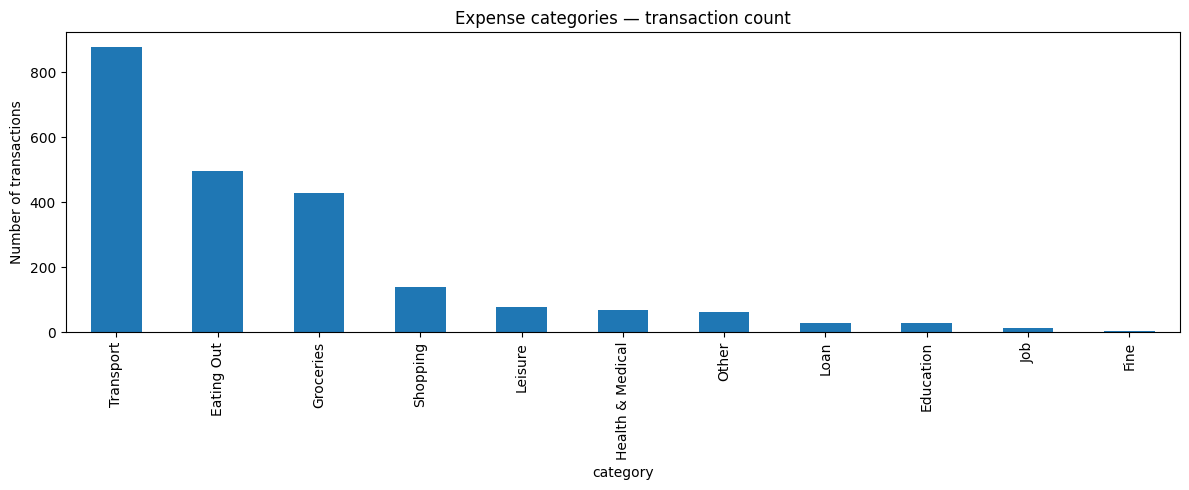

In [12]:
cat_counts = df_expenses['category'].value_counts()
cat_counts.plot(kind='bar', figsize=(12, 5), title='Expense categories — transaction count')
plt.ylabel('Number of transactions')
plt.tight_layout()
plt.show()

In [13]:
label_category = LabelEncoder()
df_expenses['category_encoded'] = label_category.fit_transform(df_expenses['category'])


In [14]:
# Sort by date first
df_expenses = df_expenses.sort_values('date').reset_index(drop=True)

# Rolling 7-day total spending
df_expenses['7day_spend'] = (
    df_expenses.set_index('date')['amount']
    .rolling('7D', min_periods=1)
    .sum()
    .values
)

# Rolling 30-day average daily spending
df_expenses['30day_avg'] = (
    df_expenses.set_index('date')['amount']
    .rolling('30D', min_periods=1)
    .mean()
    .values
)

# Spending velocity
df_expenses['spending_velocity'] = (
    df_expenses['amount'] / (df_expenses['7day_spend'] + 1)
)

print('Rolling features added.')
print(df_expenses[['date', 'amount', '7day_spend', '30day_avg', 'spending_velocity']].head(10))

Rolling features added.
        date  amount  7day_spend    30day_avg  spending_velocity
0 2024-01-07  1600.0      1600.0  1600.000000           0.999375
1 2024-01-07  1600.0      3200.0  1600.000000           0.499844
2 2024-01-08  3200.0      6400.0  2133.333333           0.499922
3 2024-01-08  6400.0     12800.0  3200.000000           0.499961
4 2024-01-08  1600.0     14400.0  2880.000000           0.111103
5 2024-01-09  1600.0     16000.0  2666.666667           0.099994
6 2024-01-09  6400.0     22400.0  3200.000000           0.285702
7 2024-01-09  4800.0     27200.0  3400.000000           0.176464
8 2024-01-09  1600.0     28800.0  3200.000000           0.055554
9 2024-01-10  1600.0     30400.0  3040.000000           0.052630


In [15]:
features_clustering = [
    'amount',
    'category_encoded',
    'day_of_week',
    'week_of_month',
    'is_weekend',
    '7day_spend',
    '30day_avg',
    'spending_velocity'
]

df_clustering = df_expenses[features_clustering].dropna()

scaler_clustering = StandardScaler()
clustered_data = scaler_clustering.fit_transform(df_clustering)

pd.DataFrame(clustered_data, columns=features_clustering).to_csv('clustered_data.csv', index=False)
df_clustering.to_csv('clustered_data_raw.csv', index=False)

print(f'Clustering dataset saved: {clustered_data.shape}')

Clustering dataset saved: (2226, 8)


In [16]:
# Create weekly aggregates
df_expenses['week'] = df_expenses['date'].dt.to_period('W')

weekly = df_expenses.groupby('week').agg(
    total_spend       = ('amount', 'sum'),
    transaction_count = ('amount', 'count'),
    avg_transaction   = ('amount', 'mean'),
    max_transaction   = ('amount', 'max'),
).reset_index()

# Add rolling features
weekly['4week_avg']        = weekly['total_spend'].rolling(4, min_periods=1).mean()
weekly['4week_max']        = weekly['total_spend'].rolling(4, min_periods=1).max()
weekly['spend_vs_avg']     = weekly['total_spend'] / (weekly['4week_avg'] + 1)
weekly['week_of_month_num'] = weekly['week'].apply(
    lambda w: (pd.Period(str(w), 'W').start_time.day - 1) // 7 + 1
)

weekly['next_week_spend'] = weekly['total_spend'].shift(-1)
weekly = weekly.dropna(subset=['next_week_spend'])

weekly.to_csv('weekly_data.csv', index=False)

print(f'Weekly dataset saved: {len(weekly)} weeks')
print(weekly.head())

Weekly dataset saved: 99 weeks
                    week  total_spend  transaction_count  avg_transaction  \
0  2024-01-01/2024-01-07       3200.0                  2      1600.000000   
1  2024-01-08/2024-01-14      89105.2                 33      2700.157576   
2  2024-01-15/2024-01-21      97024.4                 34      2853.658824   
3  2024-01-22/2024-01-28     126129.2                 35      3603.691429   
4  2024-01-29/2024-02-04      91394.8                 37      2470.129730   

   max_transaction      4week_avg  4week_max  spend_vs_avg  week_of_month_num  \
0           1600.0    3200.000000     3200.0      0.999688                  1   
1           8000.0   46152.600000    89105.2      1.930623                  2   
2           8000.0   63109.866667    97024.4      1.537364                  3   
3           8000.0   78864.700000   126129.2      1.599291                  4   
4           8000.0  100913.400000   126129.2      0.905667                  5   

   next_week_spend 